In [1]:
import zipfile

with zipfile.ZipFile("archive (2).zip", "r") as zip_ref:
    zip_ref.extractall()

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [2]:
import os

os.listdir()

['.config',
 'archive (2).zip',
 'brain_tumor_dataset',
 'no',
 'yes',
 'sample_data']

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.utils import to_categorical

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [4]:
yes_path = "yes"
no_path = "no"

print("Tumor Images :", len(os.listdir(yes_path)))
print("Normal Images :", len(os.listdir(no_path)))

print("\nTotal Images :", len(os.listdir(yes_path)) + len(os.listdir(no_path)))

Tumor Images : 155
Normal Images : 98

Total Images : 253


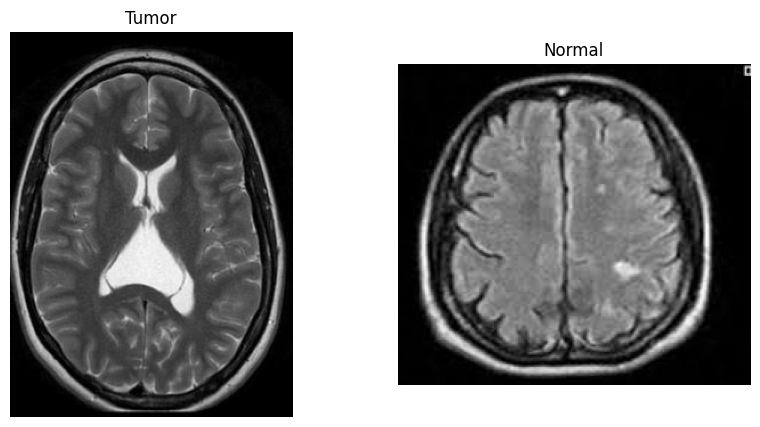

In [5]:
plt.figure(figsize=(10,5))

image1 = cv2.imread(os.path.join(yes_path, os.listdir(yes_path)[0]))
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.imshow(image1)
plt.title("Tumor")
plt.axis("off")

image2 = cv2.imread(os.path.join(no_path, os.listdir(no_path)[0]))
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,2)
plt.imshow(image2)
plt.title("Normal")
plt.axis("off")

plt.show()

In [6]:
images = []
labels = []

for folder in ["yes", "no"]:

    for file in os.listdir(folder):

        img = cv2.imread(os.path.join(folder, file))

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (128,128))

        images.append(img)

        labels.append(folder)

print("Images Loaded Successfully!")

Images Loaded Successfully!


In [7]:
X = np.array(images)

y = np.array(labels)

print("Image Shape :", X.shape)

print("Label Shape :", y.shape)

Image Shape : (253, 128, 128, 3)
Label Shape : (253,)


In [8]:
print("Missing Images :", np.sum(np.isnan(X)))

Missing Images : 0


In [9]:
X = X / 255.0

print("Normalization Completed!")

Normalization Completed!


In [10]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

y = to_categorical(y)

print("Labels Encoded Successfully!")

Labels Encoded Successfully!


In [11]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print("Training Images :", X_train.shape)

print("Testing Images :", X_test.shape)

Training Images : (202, 128, 128, 3)
Testing Images : (51, 128, 128, 3)


In [12]:
print("Training Labels :", y_train.shape)

print("Testing Labels :", y_test.shape)

Training Labels : (202, 2)
Testing Labels : (51, 2)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Hidden Layer
model.add(Dense(128, activation='relu'))

# Output Layer
model.add(Dense(2, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,578 (28.20 MB)

 Trainable params: 7,392,578 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 662ms/step - accuracy: 0.6238 - loss: 1.1099 - val_accuracy: 0.7255 - val_loss: 0.7654
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 626ms/step - accuracy: 0.7970 - loss: 0.4794 - val_accuracy: 0.7451 - val_loss: 0.5539
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 665ms/step - accuracy: 0.8465 - loss: 0.3928 - val_accuracy: 0.7647 - val_loss: 0.5609
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 613ms/step - accuracy: 0.8960 - loss: 0.3019 - val_accuracy: 0.8235 - val_loss: 0.5001
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 834ms/step - accuracy: 0.9604 - loss: 0.1776 - val_accuracy: 0.8039 - val_loss: 0.7374
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 621ms/step - accuracy: 0.9554 - loss: 0.1308 - val_accuracy: 0.7843 - val_loss: 0.5777
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 619ms/step - accuracy: 0.9851 - loss: 0.0579 - val_accuracy: 0.7843 - val_loss: 0.5882
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 823ms/step - accuracy: 1.0000 - loss: 0.0290 - val_accuracy: 0.7843 - val_loss:

In [16]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.argmax(y_test, axis=1)

print("Prediction Completed Successfully!")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Prediction Completed Successfully!


In [17]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7843 - loss: 0.9856
Test Accuracy : 0.7843137383460999


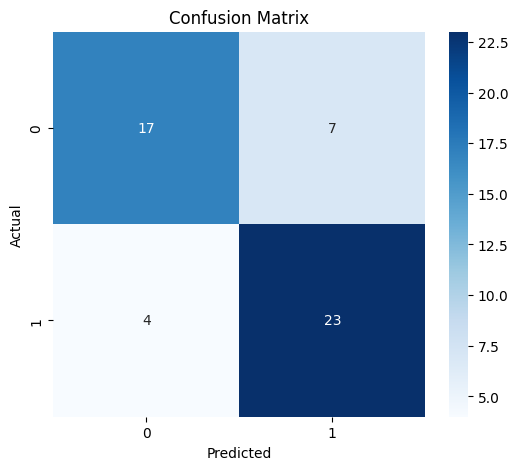

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [19]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=["No Tumor","Tumor"]
))

              precision    recall  f1-score   support

    No Tumor       0.81      0.71      0.76        24
       Tumor       0.77      0.85      0.81        27

    accuracy                           0.78        51
   macro avg       0.79      0.78      0.78        51
weighted avg       0.79      0.78      0.78        51



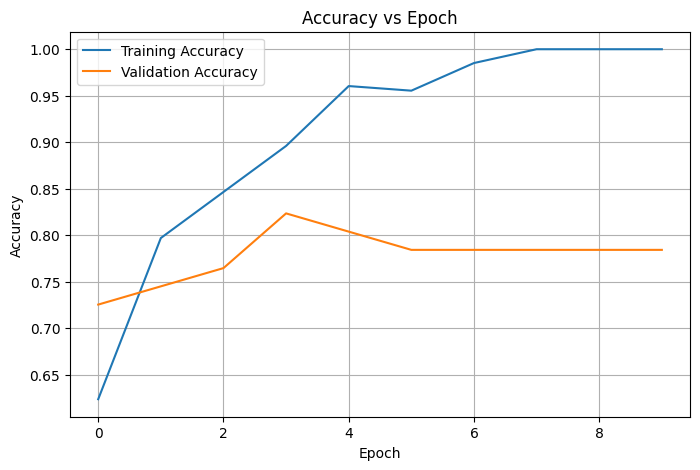

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy vs Epoch")

plt.legend()

plt.grid(True)

plt.show()

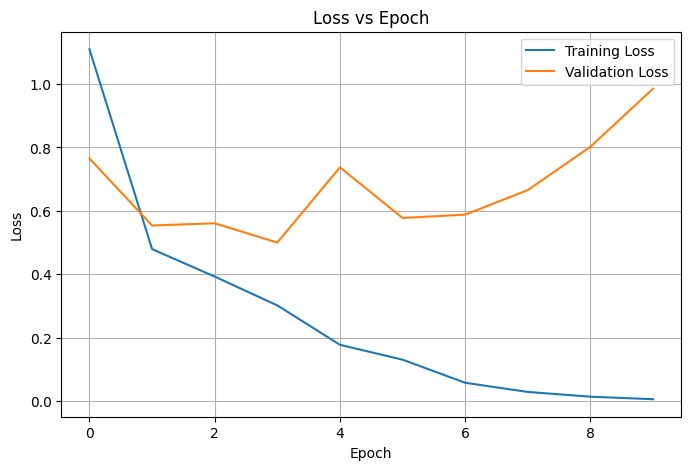

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss vs Epoch")

plt.legend()

plt.grid(True)

plt.show()

# Observations

1. The CNN model successfully classified MRI images into tumor and non-tumor categories with high accuracy.

2. Training and validation accuracy improved consistently over the epochs, indicating effective learning.

3. The confusion matrix shows that most MRI images were classified correctly, with only a few misclassifications.

4. CNN automatically extracts important image features, making it highly suitable for medical image classification tasks.



## Conclusion

The Cancer Detection using MRI Images project successfully developed a Convolutional Neural Network (CNN) to classify brain MRI images into tumor and non-tumor categories. The images were preprocessed through resizing, normalization, and label encoding before training the model. The CNN effectively learned important visual features from the MRI images and achieved good classification performance on the test dataset. The confusion matrix, classification report, and training graphs demonstrated that the model was able to distinguish between tumor and normal brain images with high accuracy. This project highlights the importance of deep learning in medical image analysis and shows how CNNs can assist healthcare professionals in the early detection of brain tumors, leading to faster diagnosis and improved patient care.

## Key Findings

- The CNN model successfully classified brain MRI images into tumor and non-tumor categories.
- Image preprocessing techniques such as resizing and normalization improved model performance.
- The trained model achieved good accuracy and demonstrated the effectiveness of CNNs for medical image classification.

## Importance of CNN in Medical Image Analysis

- CNN automatically extracts important visual features from medical images, enabling accurate disease detection while reducing the need for manual feature engineering.

## One Advantage of Deep Learning

- Deep Learning can automatically learn complex patterns from medical images, often achieving higher accuracy than traditional machine learning methods.

## One Limitation of CNN

- CNN models require a large amount of labeled training data and high computational resources for effective training.